In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

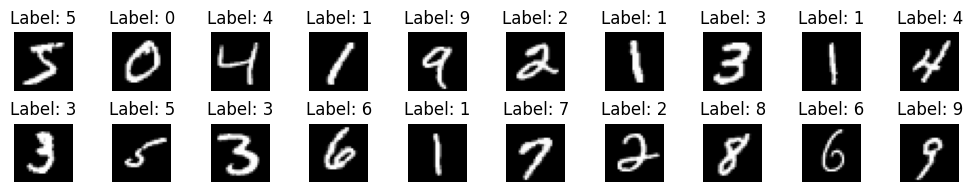

In [2]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

def show_samples(dataset, n= 20):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n//2, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')   
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


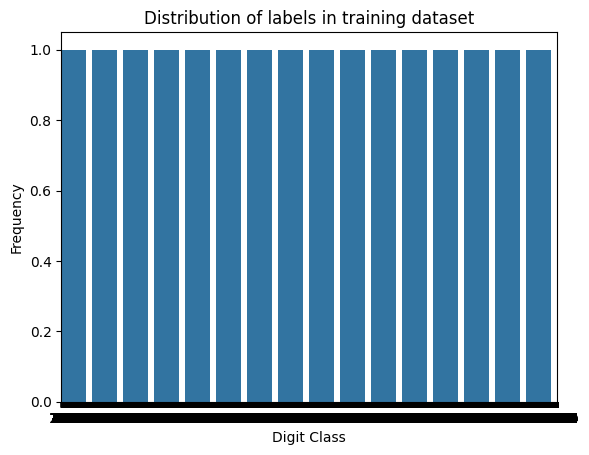

In [3]:
labels = [label for _, label in train_dataset]
sns.countplot(labels)
plt.title('Distribution of labels in training dataset')
plt.xlabel('Digit Class')
plt.ylabel('Frequency')
plt.show()



In [8]:
# --- CNN Model Definition ---
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNNModel()
print(f"Model created successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Model created successfully!
Total parameters: 206922


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    average_loss = running_loss / len(train_loader)
    train_losses.append(average_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {average_loss:.4f}")
     

Epoch 1/5, Loss: 0.0334
Epoch 2/5, Loss: 0.0257
Epoch 3/5, Loss: 0.0198
Epoch 4/5, Loss: 0.0150
Epoch 5/5, Loss: 0.0123


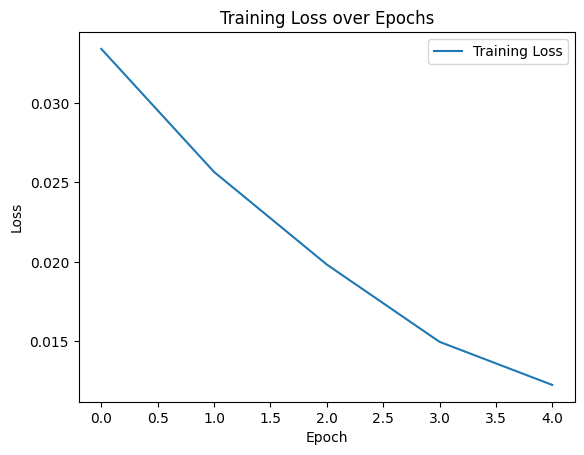

In [13]:
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()


In [17]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = outputs.max( 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print("classification_report")
print(classification_report(all_labels, all_preds))



classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



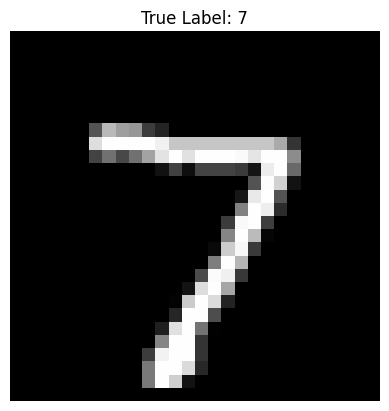

Predicted Label: 7


In [18]:
# inference on one image
sample_image, sample_label = test_dataset[0]
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f'True Label: {sample_label}')
plt.axis('off')
plt.show()

sample_image = sample_image.unsqueeze(0)
with torch.no_grad():
    output = model(sample_image)
    _, predicted = output.max(1)
    
print(f"Predicted Label: {predicted.item()}")
